In [239]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Layout
import pandas as pd

In [240]:
np.random.seed(42)

# 1. Setup Data
N= 10
n_fact = 0.5
x = np.linspace(0, 2 * np.pi, N)
x1 = np.linspace(0, 2 * np.pi, 1000) # For smooth plotting of the fit

# Ground Truth (The "Signal")
y_truth = np.sin(x)
y_truth_smooth = np.sin(x1) # For plotting the true curve smoothly

# Aleatoric Uncertainty (The "Noise")
# This is additive noise - it doesn't change based on x
noise = n_fact* np.random.normal(size=x.shape)
y_obs = y_truth + noise

def plot_poly(c0, c1, c2, c3, c4, c5, c6, c7, c8, c9):
    plt.figure(figsize=(10, 6))
    
    # Calculate polynomial: y = c0 + c1*x + c2*x^2 ...
    coeffs = [c9, c8, c7, c6, c5, c4, c3, c2, c1, c0]
    y_poly = np.polyval(coeffs, x)
    
    # Plotting
    plt.scatter(x, y_obs, color='red', s=15, alpha=0.6, label="Observed (with Aleatoric Noise)")
    plt.plot(x1, y_truth_smooth, 'k--', alpha=0.3, label="Ground Truth (sin x)")
    plt.plot(x1, np.polyval(coeffs, x1), color='blue', lw=2, label="9th Degree Poly Model")
    
    plt.ylim(-2.5, 2.5)
    plt.title("Epistemic Uncertainty: Fitting a 9th Degree Poly to Noisy Sine")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

# 2. Create the Interactive Sliders
# We define specific ranges because x^9 becomes massive quickly
# Updated interact call with range labels in the descriptions
interact(plot_poly, 
         c0=FloatSlider(min=-2, max=2, step=0.01, value=0, 
                        description='c0 [-2, 2]', readout_format='.5f'),
         c1=FloatSlider(min=-2, max=2, step=0.01, value=1, 
                        description='c1 [-2, 2]', readout_format='.5f'),
         c2=FloatSlider(min=-1, max=1, step=0.001, value=0, 
                        description='c2 [-1, 1]', readout_format='.5f'),
         c3=FloatSlider(min=-0.5, max=0.5, step=0.001, value=-0.16, 
                        description='c3 [-.5, .5]', readout_format='.5f'),
         c4=FloatSlider(min=-0.1, max=0.1, step=0.0001, value=0, 
                        description='c4 [-.1, .1]', readout_format='.5f'),
         c5=FloatSlider(min=-0.05, max=0.05, step=0.0001, value=0.008, 
                        description='c5 [-.05, .05]', readout_format='.5f'),
         c6=FloatSlider(min=-0.01, max=0.01, step=0.0001, value=0, 
                        description='c6 [-.01, .01]', readout_format='.5f'),
         c7=FloatSlider(min=-0.005, max=0.005, step=0.0001, value=0, 
                        description='c7 [-.005, .005]', readout_format='.5f'),
         c8=FloatSlider(min=-0.001, max=0.001, step=0.00001, value=0, 
                        description='c8 [-.001, .001]', readout_format='.5f'),
         c9=FloatSlider(min=-0.0005, max=0.0005, step=0.00001, value=0, 
                        description='c9 [-.0005, .0005]', readout_format='.5f',
                        style={'description_width': 'initial'})
        )

interactive(children=(FloatSlider(value=0.0, description='c0 [-2, 2]', max=2.0, min=-2.0, readout_format='.5f'…

<function __main__.plot_poly(c0, c1, c2, c3, c4, c5, c6, c7, c8, c9)>

# Objective 
$$ \{\hat{\theta} \}= \argmin_{\theta \in \mathbb{R}^Q}\underbrace{\frac{1}{N} \sum_{i=1}^{N} ||y_{obs}|_i - f(x_i; \theta)||^2}_{\text{Data Misfit}} $$
- N is total number of observation points
- $y_{obs}|_i$ is the i-th point of observation data
- $f(x_i; \theta)$ is the model, where $x_i$ is the i-th input points and $\theta \in \mathbb{R}^Q$ is our parameter. 

/var/folders/lr/h2867zhs72gcy61j6_cy0n0r0000gq/T/ipykernel_63958/3378901641.py:16: OptimizeWarning: Covariance of the parameters could not be estimated
  popt1, pcov = curve_fit(poly9, x, y_obs)


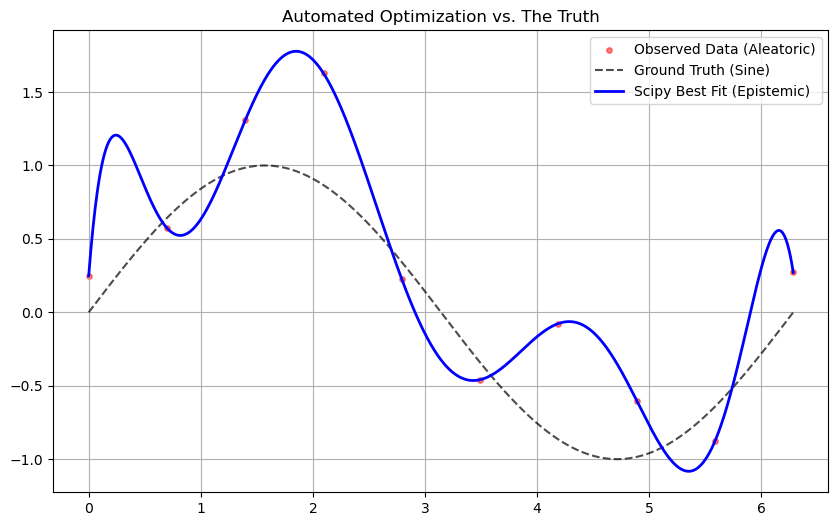

Optimized Coefficients:
   Number of points  λ        c0        c1         c2         c3         c4  \
0                10  0  0.248357  9.764414 -33.066156  43.798391 -28.204815   

         c5        c6        c7      c8        c9  
0  9.804693 -1.898214  0.196224 -0.0091  0.000089  


In [241]:

from scipy.optimize import curve_fit

# 1. Setup Data (Same as before)



# 2. Define the Model Function
# The function must take 'x' as the first argument, followed by the parameters to find
def poly9(x, c0, c1, c2, c3, c4, c5, c6, c7, c8, c9):
    return (c0 + c1*x + c2*x**2 + c3*x**3 + c4*x**4 + 
            c5*x**5 + c6*x**6 + c7*x**7 + c8*x**8 + c9*x**9)

# 3. Run the Optimization
# popt: Optimal parameters found
# pcov: The covariance matrix (This is the key to UNCERTAINTY!)
popt1, pcov = curve_fit(poly9, x, y_obs)

# 4. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(x, y_obs, color='red', s=15, alpha=0.5, label="Observed Data (Aleatoric)")
plt.plot(x1, y_truth_smooth, 'k--', alpha=0.7, label="Ground Truth (Sine)")
plt.plot(x1, poly9(x1, *popt1), color='blue', lw=2, label="Scipy Best Fit (Epistemic)")

plt.title("Automated Optimization vs. The Truth")
plt.legend()
plt.grid(True)
plt.show()

c_table ={"Number of points":N}
c_table["λ"] =0
print("Optimized Coefficients:")
for i, val in enumerate(popt1):
    c_table[f"c{i}"] = val
    #print(f"c{i}: {val:.4e}")
    
df = pd.DataFrame([c_table], columns=c_table.keys())
print(df)

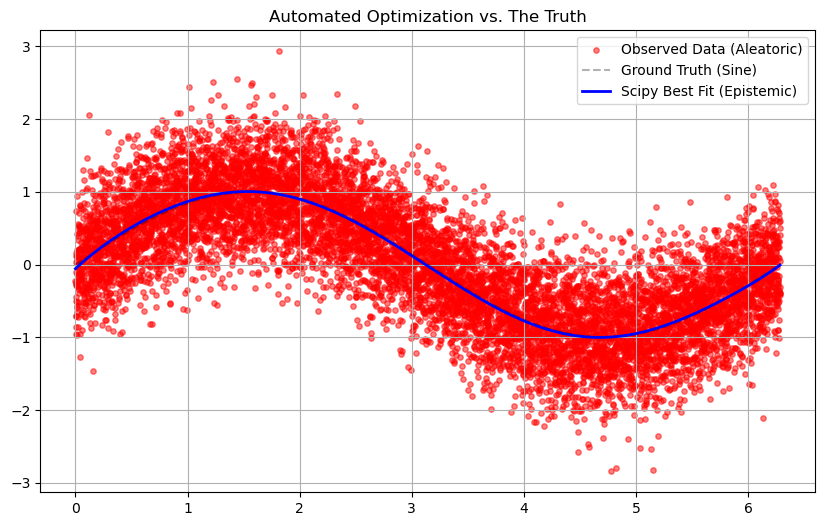

,Number of points,λ,c0,c1,c2,c3,c4,c5,c6,c7,c8,c9
0,10.0,0.0,0.248357,9.764414,-33.066156,43.798391,-28.204815,9.804693,-1.898214,0.196224,-0.009100,0.000089
1,10000.0,0.0,-0.055877,1.435940,-0.806099,0.621403,-0.490553,0.207330,-0.051421,0.007839,-0.000679,0.000025


In [242]:

from scipy.optimize import curve_fit

# 1. Setup Data (Same as before)
N3=10000
x3 = np.linspace(0, 2 * np.pi, N3)
y_truth3 = np.sin(x3)
noise = n_fact * np.random.normal(size=x3.shape)
y_obs3 = y_truth3 + noise

# 2. Define the Model Function
# The function must take 'x' as the first argument, followed by the parameters to find
def poly9(x, c0, c1, c2, c3, c4, c5, c6, c7, c8, c9):
    return (c0 + c1*x + c2*x**2 + c3*x**3 + c4*x**4 + 
            c5*x**5 + c6*x**6 + c7*x**7 + c8*x**8 + c9*x**9)

# 3. Run the Optimization
# popt: Optimal parameters found
# pcov: The covariance matrix (This is the key to UNCERTAINTY!)
popt2, pcov = curve_fit(poly9, x3, y_obs3)

# 4. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(x3, y_obs3, color='red', s=15, alpha=0.5, label="Observed Data (Aleatoric)")
plt.plot(x1, y_truth_smooth, 'k--', alpha=0.3, label="Ground Truth (Sine)")
plt.plot(x3, poly9(x3, *popt2), color='blue', lw=2, label="Scipy Best Fit (Epistemic)")

plt.title("Automated Optimization vs. The Truth")
plt.legend()
plt.grid(True)
plt.show()
row = [N3]
row.append(0) # λ
for i, val in enumerate(popt2):
    row.append(val)
df.loc[1] = row
df

# Objective 
$$ \{\hat{\theta} \}= \argmin_{\theta \in \mathbb{R}^Q} \quad (\underbrace{\frac{1}{N} \sum_{i=1}^{N} ||y_{obs}|_i - f(x_i; \theta)||^2}_{\text{Data Misfit}} + \underbrace{\lambda ||\theta||^2}_{\text{Penalty(Regularization)}})$$
- N is total number of observation points
- $y_{obs}|_i$ is the i-th point of observation data
- $f(x_i; \theta)$ is the model, where $x_i$ is the i-th input points and $\theta \in \mathbb{R}^Q$ is our parameter. 
- $\lambda$ is a hyperparameter

In [265]:
from scipy.optimize import minimize
N4 = 10
x4 = np.linspace(0, 2 * np.pi, N4)

# 1. Define the Loss Function with L2 Regularization
def regularized_loss(coeffs, x, y_obs, lam):
    # Predicted values from polynomial
    y_pred = np.polyval(coeffs[::-1], x)
    
    # Standard MSE
    mse = np.mean((y_obs - y_pred)**2)
    
    # L2 Penalty (sum of squared coefficients)
    penalty = lam * np.sum(coeffs**2)
    
    return mse + penalty

# 2. Run the Optimization
# Initial guess (all zeros)
initial_guess = np.array([-0.055877,	1.435940,	-0.806099,	0.621403,	-0.490553,	0.207330,	-0.051421,	0.007839,	-0.000679,	0.000025])
lam = 1e2 # Try changing this to see the "smoothness" change!
res = minimize(regularized_loss, initial_guess, args=(x4, y_obs, lam))

# The optimized coefficients
popt_reg = res.x
row = [N4]
row.append(lam)
row_ = row + popt_reg.tolist()
df.loc[2] = row_
df


,Number of points,λ,c0,c1,c2,c3,c4,c5,c6,c7,c8,c9
0,10.0,0.0,0.248357,9.764414,-33.066156,43.798391,-28.204815,9.804693,-1.898214,0.196224,-0.009100,0.000089
1,10000.0,0.0,-0.055877,1.435940,-0.806099,0.621403,-0.490553,0.207330,-0.051421,0.007839,-0.000679,0.000025
2,10.0,100.0,-0.055877,1.435940,-0.806099,0.621403,-0.490553,0.207330,-0.051421,0.007839,-0.000677,0.000025


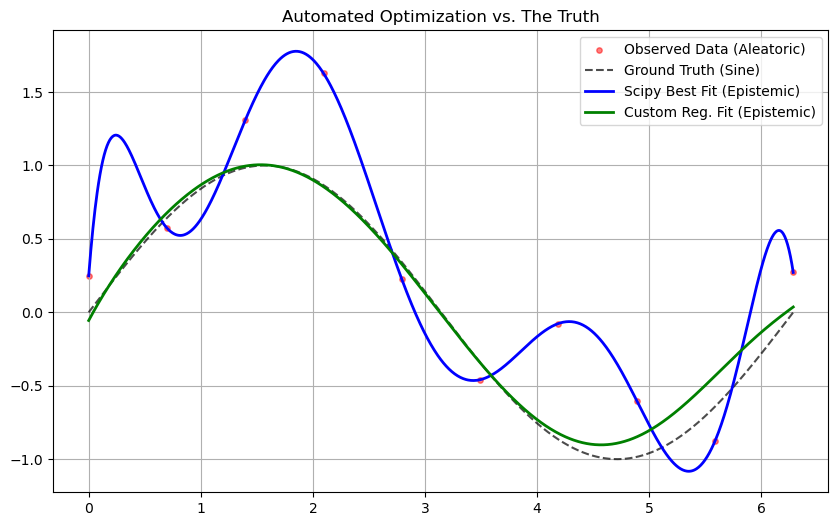

In [266]:
popt4 =popt_reg 

# 4. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(x, y_obs, color='red', s=15, alpha=0.5, label="Observed Data (Aleatoric)")
plt.plot(x1, y_truth_smooth, 'k--', alpha=0.7, label="Ground Truth (Sine)")
plt.plot(x1, poly9(x1, *popt1), color='blue', lw=2, label="Scipy Best Fit (Epistemic)")
plt.plot(x1, poly9(x1, *popt4), color='green', lw=2, label="Custom Reg. Fit (Epistemic)")

plt.title("Automated Optimization vs. The Truth")
plt.legend()
plt.grid(True)
plt.show()
